# Week 1 — Run it, then discover a real truth yourself

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/notebooks/01_first_look_and_discovery.ipynb)

By the end of this notebook you will have:
1. **Run a real ML pipeline** on real (anonymized) search data and watched a learned model beat a hand-written rule.
2. **Rediscovered a real finding yourself** in ~10 lines of pandas.

No prior ML needed. Everything runs on the small anonymized dataset that ships with this repo — no credentials, no private data.

## 0. Setup (Colab or local)
On Colab this clones the repo and installs requirements. Locally it just moves to the repo root.

In [ ]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")  # move from notebooks/ to the repo root

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"
print("Starter data found. You're ready.")

## 1. Run the whole pipeline

This runs `scripts/run_all.py`: prepare features → baseline rule → train 3 models → evaluate → PDF.
It takes ~1 minute on the 30,000-row sample.

In [ ]:
# Watch it work — each of the 5 steps prints live as it runs (~1 minute total).
!{sys.executable} scripts/run_all.py


### What just happened?
The pipeline ranked every page for "refresh review" two ways: a **hand-written rule baseline** and a **learned model**. Let's compare them on **Precision@50** — of the top 50 pages each says to fix first, how many are actually declining?

In [ ]:
import json
res = json.load(open("outputs/model_results.json"))

base = res["baseline"]["baseline_precision_at_50"]
rf   = res["models"]["random_forest"]["precision_at_50"]

print(f"Hand-written rule  Precision@50: {base:.3f}   (~{round(base*50)} of the top 50 right)")
print(f"Random forest      Precision@50: {rf:.3f}   (~{round(rf*50)} of the top 50 right)")
print(f"\nThe learned model roughly {rf/base:.1f}x the rule on this metric.")
print("Validation split used:", res["split_strategy"], "(pages from a client are never in both train and test)")

You just ran a real ML system on real search data and saw a learned ranking beat a fixed rule. Now open `outputs/model_report.md` and skim it — that Markdown report is the *shape* of what your own capstone should produce.

## 2. Discover a real truth yourself

The safest, most satisfying early wins are **things you find in the data** — un-leakable, and they *are* the core lesson. Run the three cells below. Each is ~10 lines of pandas and each overturns a common SEO belief.

Every number is **computed live from the shipped CSV** — nothing is hardcoded.

In [ ]:
import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print(df.shape[0], "rows,", df.shape[1], "columns")
df.head(3)

### Discovery A — "High search volume means more traffic." Does it?

In [ ]:
corr = df["search_volume"].corr(df["impressions_90d"])
print(f"Correlation between search_volume and impressions_90d: {corr:.3f}")
print("Near zero -> keyword search volume barely predicts the traffic a page actually gets.")

### Discovery B — the CTR cliff by position
Click-through rate is not flat: it collapses as you move down the results.

In [ ]:
visible = df[df["impressions_90d"] >= 100]
ctr_by_pos = visible.groupby("position_tier")["ctr"].mean().sort_values(ascending=False)
print(ctr_by_pos.round(4).to_string())
ctr_by_pos.plot(kind="bar", title="Mean CTR by position tier (impressions >= 100)", ylabel="CTR");

### Discovery C — is longer content the lever?
Compare word count for **declining** vs **growing** pages.

In [ ]:
wc = df.groupby("trend_direction")["word_count"].median()
print(wc.round(0).to_string())
print("\n'down' vs 'up' pages have almost the same median word count -> length is not the lever.")

## 3. 🔧 Your turn

Pick **one** of these and write a few lines below. This is your Week-1 discovery — you'll reference it in your Week-1 research-question write-up (on the InternHQ board).

- Redo Discovery A but only for pages with `impressions_90d > 0` — does the correlation change?
- In Discovery B, which `content_type` has the worst CTR *at the same position tier*?
- Find another belief to test: does `content_age_days` relate to `trend_direction`? Does `avg_position` relate to `ctr`?

**Rules:** describe what you observe as *observed / directional* — never "I proved Google's algorithm." Keep client data out of anything you publish.

Correlation between search_volume and impressions_90d (only impressions > 0): 0.001
Observation: Even after excluding zero-impression pages, the relationship remains weak.
Average CTR by Position Tier and Content Type
position_tier  content_type      
deep           feedly article        0.0440
               keyword article       0.0555
page_1         comparison article    0.1412
               feedly article        0.9048
               keyword article       0.3458
page_3_5       comparison article    0.0940
               feedly article        0.1656
               keyword article       0.1427
striking       comparison article    0.1474
               feedly article        0.3580
               keyword article       0.2559
top_3          comparison article    0.0000
               feedly article        2.9000
               keyword article       0.3104
Name: ctr, dtype: float64

Worst CTR content type within each position tier:
                     content_type       ctr
position_ti

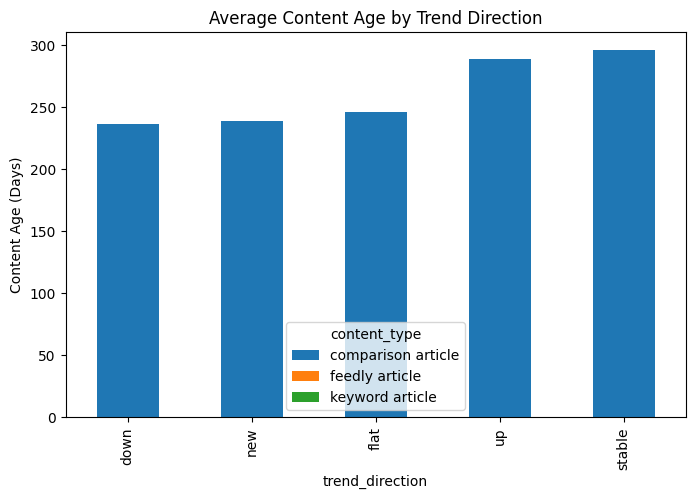

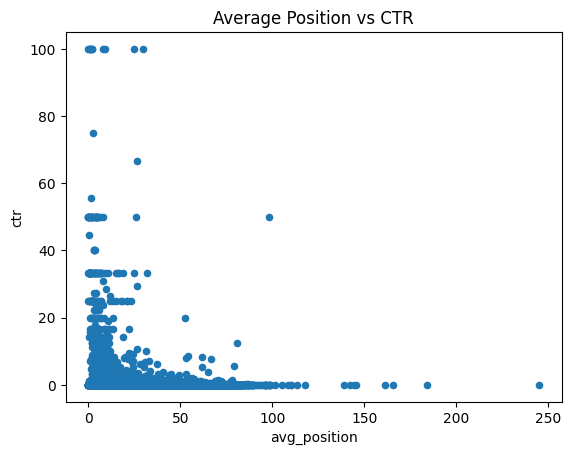

In [13]:
# Your discovery here
# Week-1 Discovery Option 1

visible = df[df["impressions_90d"] > 0]

corr = visible["search_volume"].corr(visible["impressions_90d"])

print(f"Correlation between search_volume and impressions_90d (only impressions > 0): {corr:.3f}")

if abs(corr) < 0.3:
    print("Observation: Even after excluding zero-impression pages, the relationship remains weak.")
elif corr > 0:
    print("Observation: The positive relationship becomes stronger after removing zero-impression pages.")
else:
    print("Observation: A negative relationship is observed.")

    # Week-1 Discovery Option 2

visible = df[df["impressions_90d"] >= 100]

ctr_table = (
    visible
    .groupby(["position_tier", "content_type"])["ctr"]
    .mean()
    .round(4)
)

print("Average CTR by Position Tier and Content Type")
print(ctr_table)

# Find the lowest CTR content type within each position tier
worst_ctr = (
    visible
    .groupby(["position_tier", "content_type"])["ctr"]
    .mean()
    .reset_index()
    .sort_values(["position_tier", "ctr"])
    .groupby("position_tier")
    .first()
)

print("\nWorst CTR content type within each position tier:")
print(worst_ctr)

# Visualization
(
    visible
    .groupby(["position_tier","content_type"])["ctr"]
    .mean()
    .unstack()
    .plot(kind="bar",
          figsize=(8,5),
          title="Average CTR by Position Tier and Content Type",
          ylabel="CTR")
);

# Week-1 Discovery Option 3A

age_by_trend = (
    df.groupby("trend_direction")["content_age_days"]
      .mean()
      .sort_values()
)

print(age_by_trend.round(2).to_string())

age_by_trend.plot(
    kind="bar",
    title="Average Content Age by Trend Direction",
    ylabel="Content Age (Days)"
);


# Week-1 Discovery Option 3B

corr = df["avg_position"].corr(df["ctr"])

print(f"Correlation between avg_position and ctr: {corr:.3f}")

if corr < 0:
    print("Observation: Better average positions tend to have higher CTR.")
elif corr > 0:
    print("Observation: Higher average positions tend to have higher CTR.")
else:
    print("Observation: Little to no relationship is observed.")

df.plot.scatter(
    x="avg_position",
    y="ctr",
    title="Average Position vs CTR"
);


### Save your work
**Colab:** *File → Save a copy in GitHub* (writes to your own repo — that's your submission) and *File → Save a copy in Drive* (so the session doesn't evaporate).

Next: `02_your_first_readable_model.ipynb` — where the model becomes a rule you can read.